In [1]:
import pandas as pd
import json
import numpy as np
import multiprocessing as mp
import seaborn as sns
import matplotlib.pyplot as plt
from catomatic.BinaryCatalogue import BinaryBuilder
import pathlib
import ast
import os

from protocols import utils, functions, graphs

plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Helvetica'  
plt.rcParams['figure.figsize'] = (6.69, 5.02)

%load_ext autoreload
%autoreload 2

# Run Grid Search on Training set

We want to find the best performing parameters on the training set. 

We vary confidence level (0.90 and 0.95) and background (null) value, and compare performances.

Note, this uses multiprocessing implemented for Unix/MacOS, and may need to be adapted for Windows.

In [ ]:
# the path to the CRyPTIC v3.1.0 data tables (including the DST_MEASUREMENTS_+.pkl which has DST for the validation samples appended)
cryptic_tables_path = 'data/cryptic-tables-v3.4.0/'

#read in genes relevant to each drug
with open('data/drug_to_genes.json', 'r') as f:
    drug_genes = json.load(f)

# whether to run the processes which take a long time.
# False will just read in the pre-generated results
run_long_processes = False

# number of cores
n_cores = 9

In [3]:

def process_grid_search(args):
    '''
    Process one combination of drug, background, and p-value.

    Builds a catalogue and tests its performance. Uses the workflow in 01-examplar.ipynb
    '''

    drug, genes, mutations_dir, phenotypes_path, samples_path, mut_path, var_path, catfile_dir, FRS, background, p, geno_version, pheno_version = args

    results = {}

    mutations = functions.prep_mutations(mutations_dir, genes, version=geno_version, mut_path=mut_path, var_path=var_path, train=True)
    
    test_mutations = functions.prep_mutations(mutations_dir, genes, version=geno_version, mut_path=mut_path, var_path=var_path, train=False)
    
    phenotypes = functions.prep_phenotypes(drug, phenotypes_path, samples_path , version=pheno_version, validation=False)
    
    catfile = f"{catfile_dir}/{drug.lower()}/bg_{background}_p_{p}_FRS_{np.round(FRS,1)}.csv"
    
    catalogue = BinaryBuilder(samples=phenotypes, mutations=mutations, frs=FRS, seed=drug_genes[drug]['phylogenetic']).build(test='Binomial', background=background, strict_unlock=True, p=p)
    
    catalogue.to_piezo(genbank_ref='NC00962.3', catalogue_name=f'{drug}-{background}-{p}', version='0.0', 
                        drug=drug, wildcards=f"./data/wildcards/{drug.lower()}_wildcards.json", json_dumps=True, outfile=catfile)

    all_data = pd.merge(phenotypes, test_mutations[test_mutations.FRS >= 0.1], on=['UNIQUEID'], how='left')
    
    cmx, dpr, sens, spec, ppv, sens2, spec2 = functions.piezo_predict(iso_df=all_data, drug=drug, catalogue_file=catfile)
    
    results[(drug, background, p)] = {"cm": cmx, "dpr": dpr, "sens": sens, "spec": spec, "sens2": sens2, "spec2": spec2}
    
    return results


def parallel_grid_search(mutations_dir, phenotypes_path, samples_path, mut_path, var_path, catfile_dir, FRS, geno_version, pheno_version, cores):
    '''
    Main function for parallel execution.

    Defines background values and confidence levels
    '''
    grid_results = {}
    
    # Create list of tasks to parallelize
    tasks = []
    
    for drug, data in drug_genes.items():

        genes = data['genes']

        for background in [0.05, 0.10, 0.15, 0.20, 0.25]:
            for p in [0.9, 0.95]:
        
                tasks.append((drug, genes, mutations_dir, phenotypes_path, samples_path, mut_path, var_path, catfile_dir, FRS, background, p, geno_version, pheno_version))

    ctx = mp.get_context("fork")  
    num_workers = min(cores, len(tasks))
    
    with ctx.Pool(num_workers) as pool:
        all_results = pool.map(process_grid_search, tasks)  # Run in parallel

    for result in all_results:
        grid_results.update(result)
    return grid_results


In [4]:
#best to run with 1 core when first run, as the memory requirements are steep 
# when first processing the mutations tables (thereafter they are automatically read in)

if run_long_processes:

   # run grid search on crypticv1 samples
   grid_results = parallel_grid_search(
      "data/mutations-v3.4.0/",
      cryptic_tables_path+"DST_MEASUREMENTS.parquet",
      cryptic_tables_path+"WGS_SAMPLES.parquet",
      cryptic_tables_path+"MUTATIONS.parquet",
      cryptic_tables_path+"VARIANTS.parquet",
      "catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search", #outdir
      0.1, #FRS
      'v3.4.0', #genome table version
      'v3.4.0', #phenotype table version 
      cores=n_cores 
   )

   df = utils.flatten_grid_results(grid_results)

   df.to_csv('results/grid_search/MTBC-CRyPTICv1.1.1-2025.8_grid_results_.csv')

else: 
   
   df = pd.read_csv('results/grid_search/MTBC-CRyPTICv1.1.1-2025.8_grid_results_.csv')

df

,DRUG,BACKGROUND_RATE,conf_level,SENSITIVITY,SPECIFICITY,DPR,SENSITIVITY2,SPECIFICITY2
0,RIF,0.05,0.90,0.962742,0.977818,0.966361,0.960011,0.978851
1,RIF,0.05,0.95,0.962728,0.977830,0.964171,0.959645,0.978928
2,RIF,0.10,0.90,0.962257,0.978266,0.974311,0.956534,0.979004
3,RIF,0.10,0.95,0.962612,0.978189,0.971796,0.956534,0.979004
4,RIF,0.15,0.90,0.961903,0.978377,0.977908,0.956534,0.979004
...,...,...,...,...,...,...,...,...
145,CAP,0.15,0.95,0.810044,0.977243,0.955365,0.776151,0.978265
146,CAP,0.20,0.90,0.809160,0.977391,0.961172,0.776151,0.978265
147,CAP,0.20,0.95,0.809160,0.977302,0.957705,0.776151,0.978265
148,CAP,0.25,0.90,0.808279,0.977427,0.962645,0.776151,0.978265


In [5]:
df[df.DRUG=='ETH']

,DRUG,BACKGROUND_RATE,conf_level,SENSITIVITY,SPECIFICITY,DPR,SENSITIVITY2,SPECIFICITY2
120,ETH,0.05,0.90,0.908987,0.869838,0.896154,0.823346,0.883667
121,ETH,0.05,0.95,0.907537,0.873970,0.889940,0.809144,0.887892
122,ETH,0.10,0.90,0.898026,0.884666,0.900090,0.756495,0.894533
123,ETH,0.10,0.95,0.894017,0.905240,0.877097,0.724628,0.915316
124,ETH,0.15,0.90,0.887090,0.917484,0.864738,0.683062,0.926699
125,ETH,0.15,0.95,0.885872,0.921422,0.853000,0.666782,0.931011
126,ETH,0.20,0.90,0.869227,0.930975,0.871228,0.658469,0.937910
127,ETH,0.20,0.95,0.866791,0.936000,0.864600,0.644614,0.942739
128,ETH,0.25,0.90,0.866791,0.936062,0.865290,0.644614,0.942739
129,ETH,0.25,0.95,0.858346,0.944099,0.849617,0.600277,0.950414


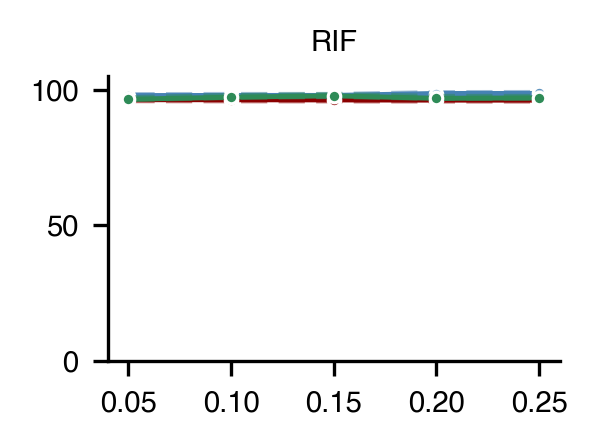

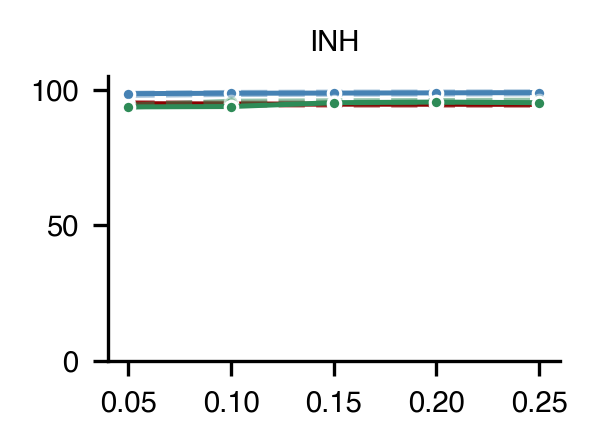

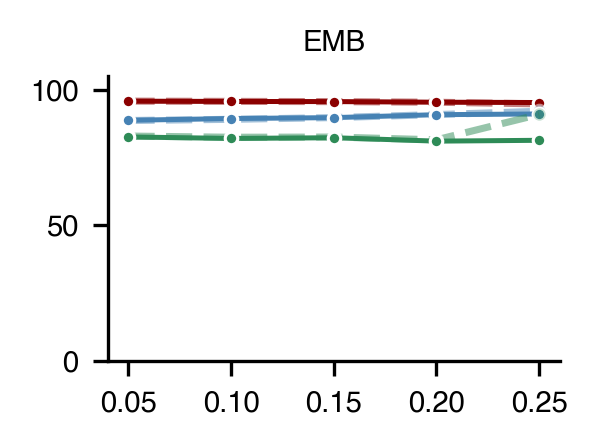

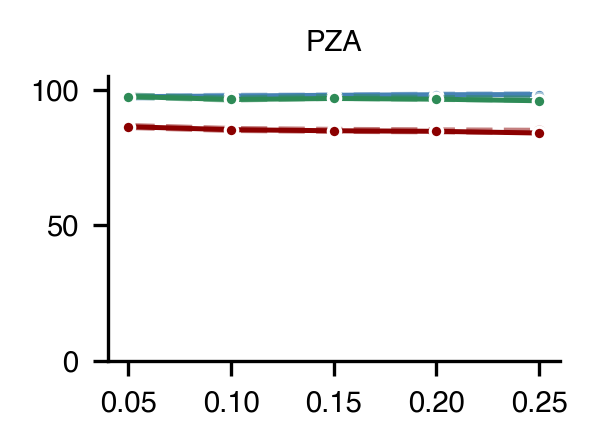

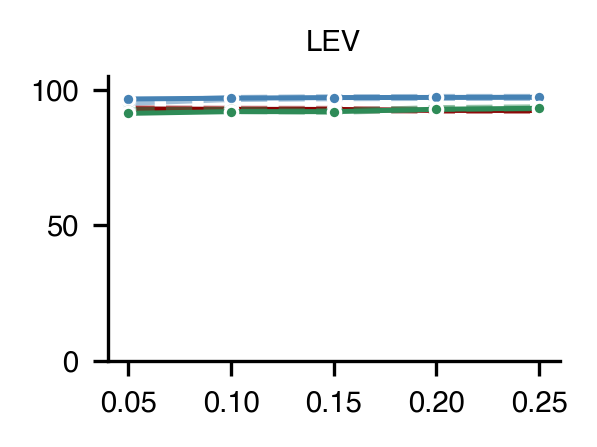

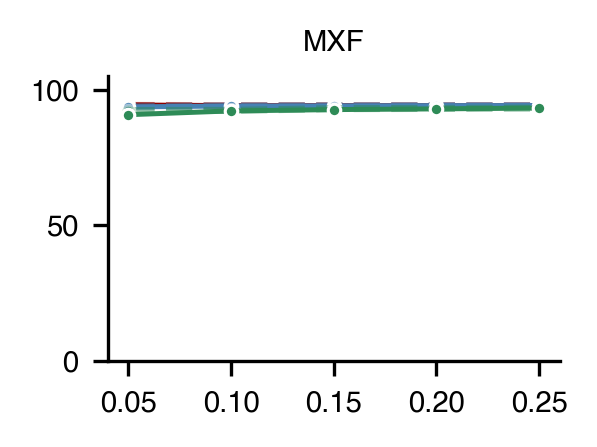

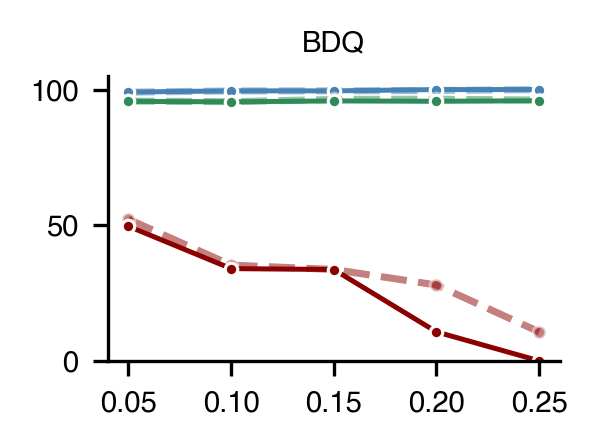

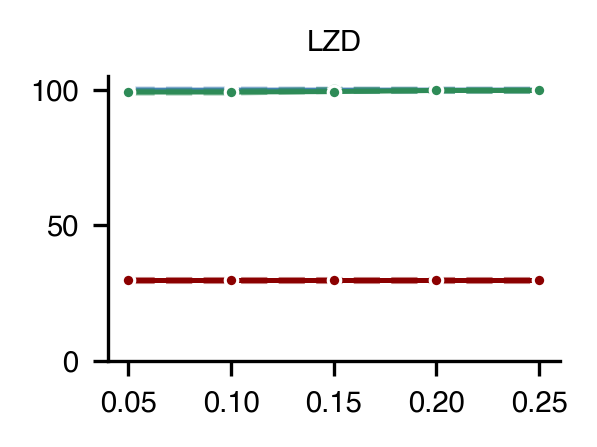

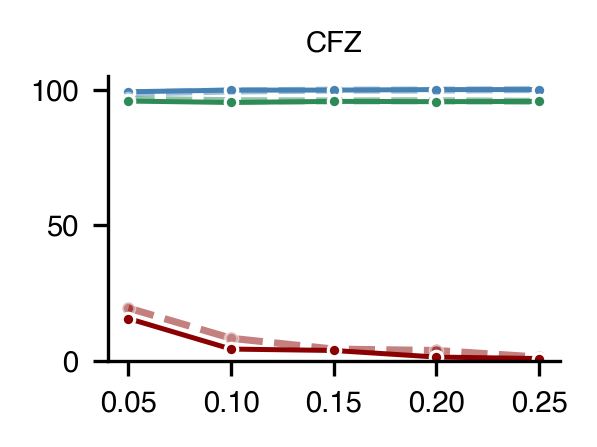

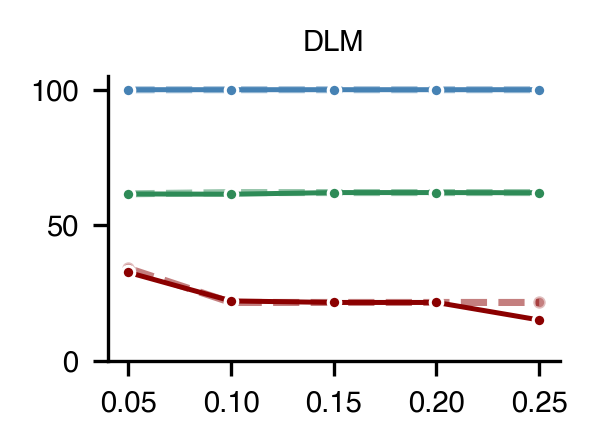

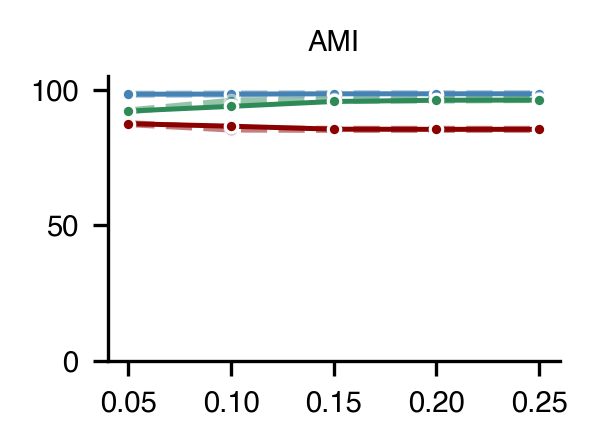

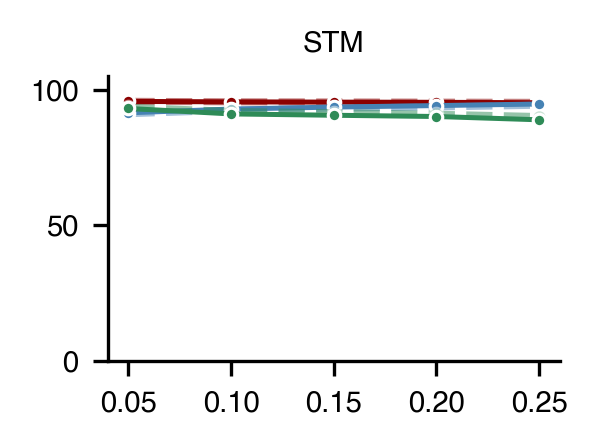

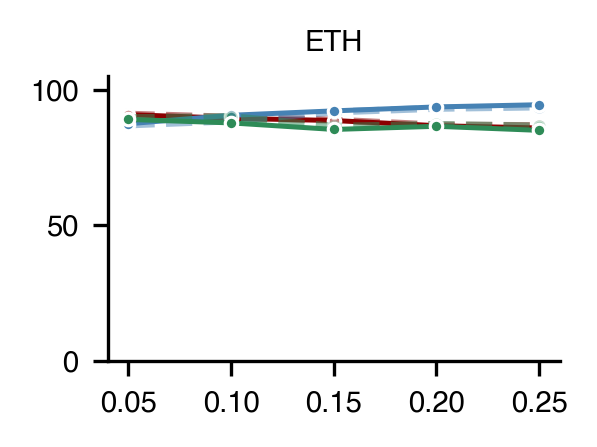

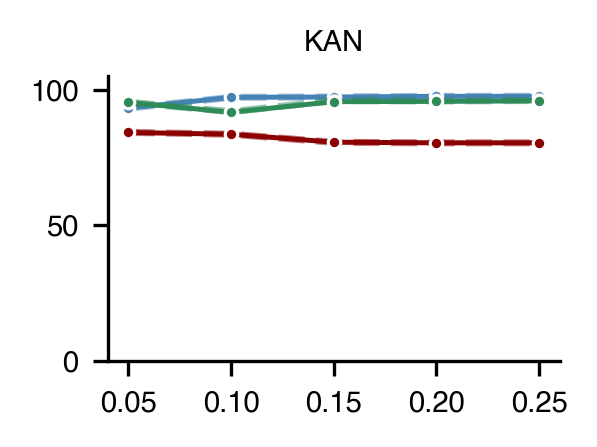

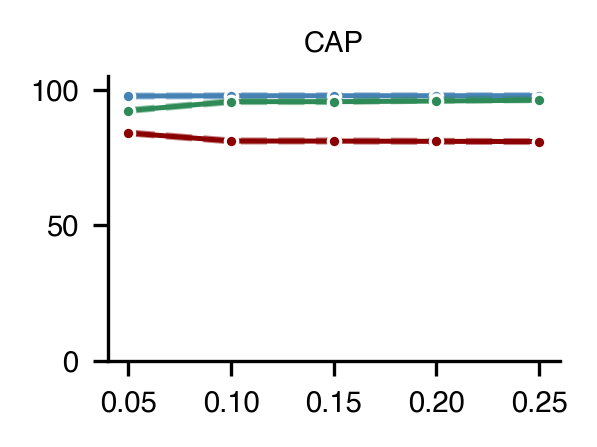

In [6]:
# Melt the DataFrame for plotting
melted_df = df.melt(
    id_vars=["DRUG", "BACKGROUND_RATE", "conf_level"],
    value_vars=["SENSITIVITY", "SPECIFICITY", "DPR"],
    var_name="Metric",
    value_name="Value",
)

melted_df['value'] = 100* melted_df['Value']
melted_df.drop(columns=['Value'], inplace=True)

graphs.grid_search_plots(melted_df)

# Use weighted score to choose best performing catalogue

We now choose a set of parameters for each drug. 

An arbitrarily weighted cost function to balance sensitivity, specificity, and DPR is sufficient for this task.

In [7]:
#determine the best performing catalogue
opt_cats = functions.weighted_score(df).groupby("DRUG").head(1).reset_index(drop=True)

cat_counts = []

#display performance and label counts
for i in opt_cats.index:
    drug = opt_cats['DRUG'][i]
    rate = opt_cats['BACKGROUND_RATE'][i]
    pval = opt_cats['conf_level'][i]

    path = f"./catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/{drug.lower()}/bg_{rate}_p_{pval}_FRS_0.1.csv"
    cat = pd.read_csv(path)

    # Filter out rules
    cat = cat[cat['EVIDENCE'].apply(lambda x: ast.literal_eval(x) != {"default_rule": "True"})]

    # Skip if empty after filtering
    if cat.empty:
        continue

    cat_counts.append({
        "DRUG": drug,
        "R": cat["PREDICTION"].value_counts().get("R", 0),
        "S": cat["PREDICTION"].value_counts().get("S", 0),
        "U": cat["PREDICTION"].value_counts().get("U", 0),
        "Total": len(cat)
    })

# Convert to DataFrame
cat_counts = pd.DataFrame(cat_counts)

# Merge and save
opt_cats = pd.merge(opt_cats, cat_counts, on='DRUG')
opt_cats['catalogue'] = 'MTBC-CRyPTICv1.1.1-2025.8'
#opt_cats.loc[:, 'conf_level'] = 1 - opt_cats.conf_level.values
opt_cats.to_csv('results/grid_search/opt_cats_MTBC-CRyPTICv1.1.1-2025.8.csv', index=False)

# Display result
opt_cats

,DRUG,BACKGROUND_RATE,conf_level,SENSITIVITY,SPECIFICITY,DPR,SENSITIVITY2,SPECIFICITY2,Score,R,S,U,Total,catalogue
0,RIF,0.20,0.90,0.961417,0.985268,0.971120,0.943997,0.985760,0.970513,42,16,352,410,MTBC-CRyPTICv1.1.1-2025.8
1,INH,0.25,0.90,0.945534,0.987895,0.956970,0.917435,0.988510,0.960530,62,23,626,711,MTBC-CRyPTICv1.1.1-2025.8
2,STM,0.15,0.90,0.954290,0.931818,0.914743,0.896104,0.938396,0.939639,115,8,542,665,MTBC-CRyPTICv1.1.1-2025.8
3,LEV,0.25,0.90,0.923222,0.971103,0.932654,0.894161,0.973286,0.939473,13,19,330,362,MTBC-CRyPTICv1.1.1-2025.8
4,MXF,0.25,0.95,0.940669,0.941006,0.931879,0.914180,0.945520,0.939012,11,22,489,522,MTBC-CRyPTICv1.1.1-2025.8
5,EMB,0.25,0.90,0.947307,0.919858,0.908448,0.875294,0.927433,0.931300,20,58,1056,1134,MTBC-CRyPTICv1.1.1-2025.8
6,PZA,0.05,0.90,0.863924,0.972718,0.976187,0.855799,0.973436,0.919015,440,0,143,583,MTBC-CRyPTICv1.1.1-2025.8
7,AMI,0.05,0.90,0.874486,0.982756,0.921091,0.851703,0.984194,0.916288,11,6,383,400,MTBC-CRyPTICv1.1.1-2025.8
8,CAP,0.05,0.90,0.840217,0.976051,0.922950,0.808577,0.977981,0.897514,43,2,234,279,MTBC-CRyPTICv1.1.1-2025.8
9,ETH,0.05,0.90,0.908987,0.869838,0.896154,0.823346,0.883667,0.894676,298,0,325,623,MTBC-CRyPTICv1.1.1-2025.8


## Visiualise weights response surface

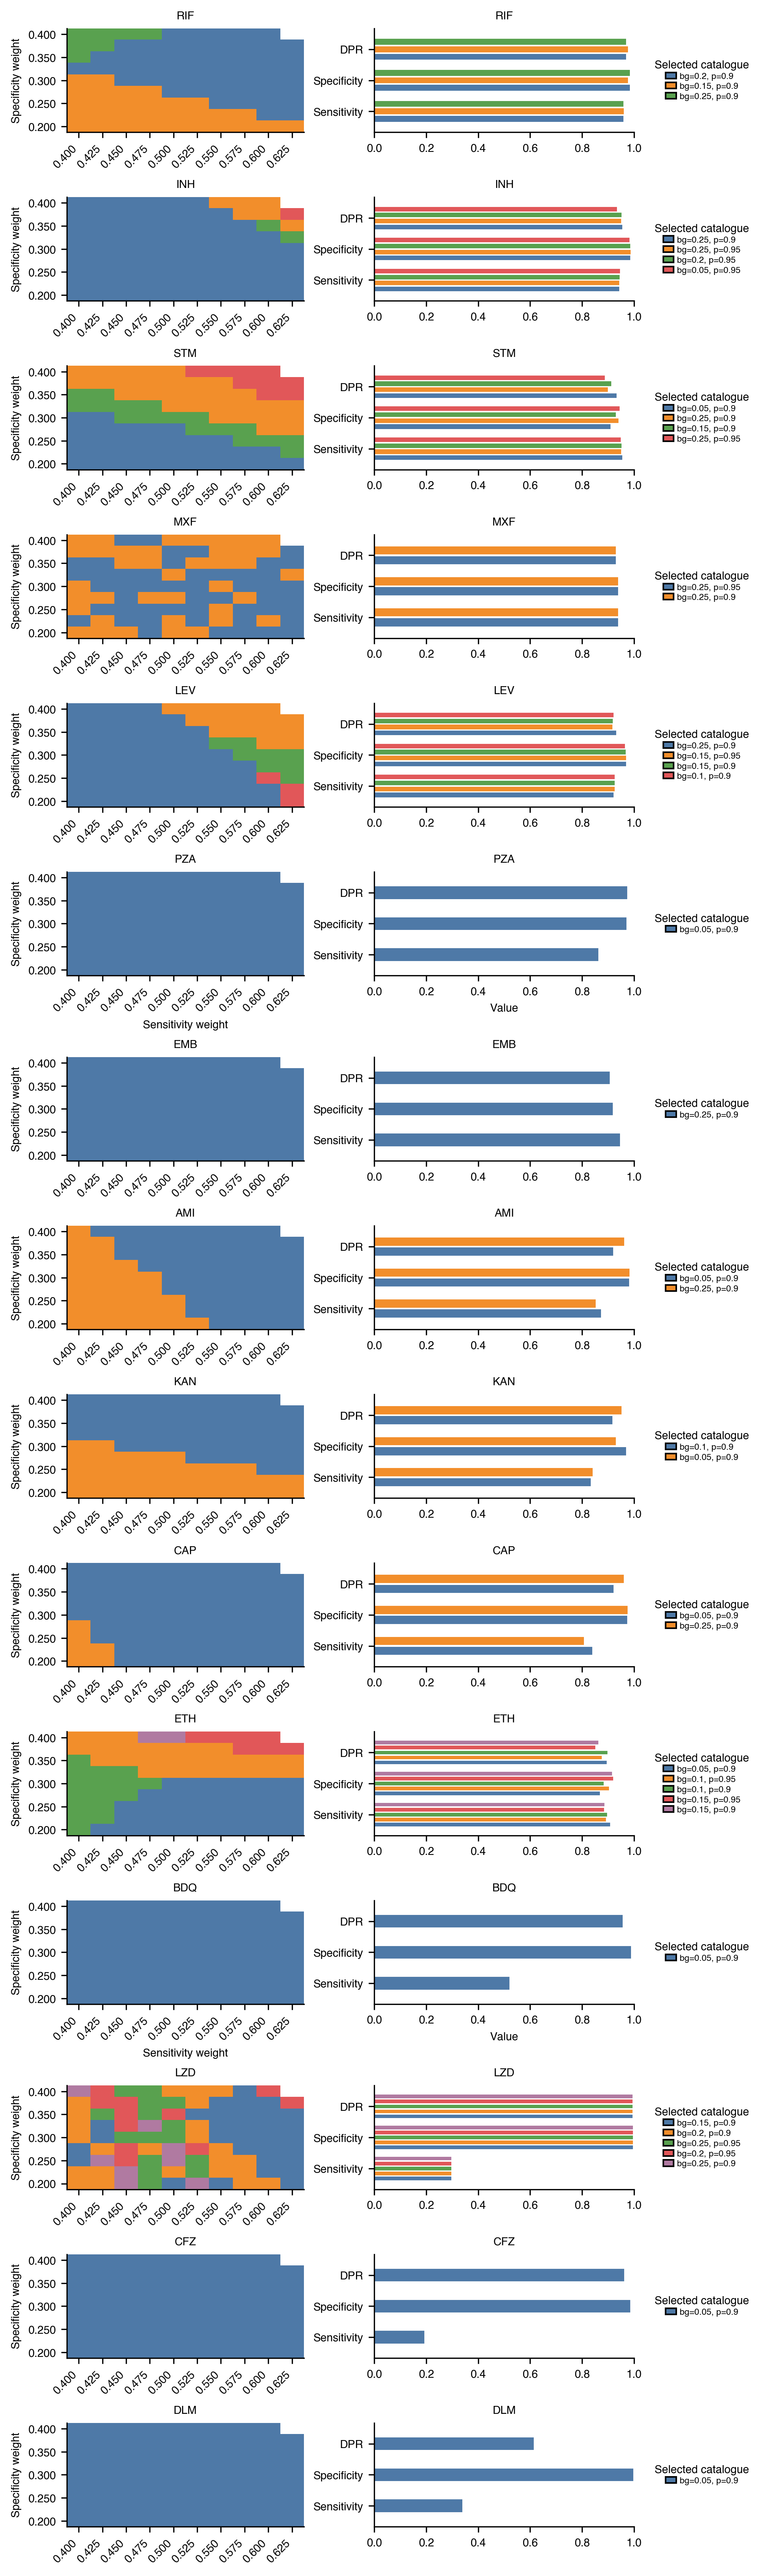

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm


def make_param_id(row):
    return f"bg={row['BACKGROUND_RATE']}, p={row['conf_level']}"


sens_vals = np.round(np.arange(0.40, 0.65, 0.025), 3)
spec_vals = np.round(np.arange(0.20, 0.4001, 0.025), 3)

weight_grid = []
for w_sens in sens_vals:
    for w_spec in spec_vals:
        w_dpr = np.round(1.0 - (w_sens + w_spec), 3)
        if w_dpr >= 0.0 and np.isclose(w_sens + w_spec + w_dpr, 1.0):
            weight_grid.append((float(w_sens), float(w_spec), float(w_dpr)))

selection_rows = []


for w_sens, w_spec, w_dpr in weight_grid:
    scored = df.copy()
    scored["Score"] = (
        w_sens * scored["SENSITIVITY"] +
        w_spec * scored["SPECIFICITY"] +
        w_dpr * scored["DPR"]
    )

    best = (
        scored.sort_values("Score", ascending=False)
        .groupby("DRUG", as_index=False)
        .head(1)
        .copy()
    )

    best["w_sens"] = w_sens
    best["w_spec"] = w_spec
    best["w_dpr"] = w_dpr
    best["param_id"] = best.apply(make_param_id, axis=1)

    selection_rows.append(
        best[[
            "DRUG", "w_sens", "w_spec", "w_dpr", "param_id",
            "BACKGROUND_RATE", "conf_level", "SENSITIVITY", "SPECIFICITY", "DPR"
        ]]
    )

selection_df = pd.concat(selection_rows, ignore_index=True)


nice_palette = [
    "#4E79A7", "#F28E2B", "#59A14F", "#E15759",
    "#B07AA1", "#76B7B2", "#EDC948", "#9C755F",
    "#BAB0AC", "#86BCB6", "#D37295", "#8CD17D"
]

drugs = selection_df["DRUG"].drop_duplicates().tolist()

fig, axes = plt.subplots(
    len(drugs), 3,
    figsize=(6.6, 1.5 * len(drugs)),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [1.05, 1.15, 0.4]}
)

if len(drugs) == 1:
    axes = np.array([axes])

for i, drug in enumerate(drugs):
    sub = selection_df[selection_df["DRUG"] == drug].copy()

    # Order catalogues by frequency
    param_levels = sub["param_id"].value_counts().index.tolist()
    code_map = {p: j for j, p in enumerate(param_levels)}
    sub["param_code"] = sub["param_id"].map(code_map)

    # Colour mapping
    color_map = {
        p: nice_palette[j % len(nice_palette)]
        for j, p in enumerate(param_levels)
    }

    ax = axes[i, 0]

    pivot = (
        sub.pivot(index="w_spec", columns="w_sens", values="param_code")
        .sort_index(ascending=False)
    )

    cmap = ListedColormap([color_map[p] for p in param_levels])
    norm = BoundaryNorm(np.arange(-0.5, len(param_levels) + 0.5, 1), cmap.N)

    ax.imshow(pivot.values, aspect="auto", interpolation="nearest", cmap=cmap, norm=norm)

    ax.set_title(f"{drug}", fontsize=7)
    if i % 6 == 5:
        ax.set_xlabel("Sensitivity weight", fontsize=7)
    else:
        ax.set_xlabel("")

    ax.set_ylabel("Specificity weight", fontsize=7)

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([f"{x:.3f}" for x in pivot.columns], rotation=45, ha="right", fontsize=7)

    yticks = np.arange(0, len(pivot.index), 2)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{pivot.index[j]:.3f}" for j in yticks], fontsize=7)


    ax2 = axes[i, 1]

    metrics = ["SENSITIVITY", "SPECIFICITY", "DPR"]
    metric_labels = ["Sensitivity", "Specificity", "DPR"]

    n_cat = len(param_levels)

    # adaptive spacing
    bar_h = min(0.18, 0.8 / (n_cat + 1))
    cat_span = bar_h * (n_cat + 1)

    group_gap = cat_span * 1.04   # slightly tighter than before
    group_centers = np.arange(len(metrics)) * group_gap

    # offsets within each group
    if n_cat == 1:
        cat_offsets = np.array([0.0])
    else:
        cat_offsets = np.linspace(-(n_cat - 1) / 2, (n_cat - 1) / 2, n_cat) * bar_h

    for m_idx, metric in enumerate(metrics):
        y0 = group_centers[m_idx]

        for c_idx, p in enumerate(param_levels):
            row = sub[sub["param_id"] == p].iloc[0]

            ax2.barh(
                y0 + cat_offsets[c_idx],
                row[metric],
                height=bar_h * 0.9,
                color=color_map[p],
                edgecolor="white",
                linewidth=0.5,
            )

    ax2.set_yticks(group_centers)
    ax2.set_yticklabels(metric_labels, fontsize=7)
    ax2.set_xlim(0, 1.0)
    if i % 6 == 5:
        ax2.set_xlabel("Value", fontsize=7)
    else:
        ax2.set_xlabel("")
    ax2.set_title(f"{drug}", fontsize=7)

    ax2.set_ylim(
        group_centers[0] - cat_span * 0.7,
        group_centers[-1] + cat_span * 0.7
    )

    # clean spines
    for a in (ax, ax2):
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

    # -------------------------
    # RIGHT: legend panel
    # -------------------------
    ax3 = axes[i, 2]
    ax3.axis("off")

    legend_handles = [
        Patch(facecolor=color_map[p], edgecolor="black", label=p)
        for p in param_levels
    ]

    ax3.legend(
        handles=legend_handles,
        title="Selected catalogue",
        loc="center left",
        frameon=False,
        fontsize=5.5,
        title_fontsize=7,
        borderaxespad=0.0,
        handlelength=1.2,
        handletextpad=0.4,
        labelspacing=0.25
    )

plt.show()


In [9]:
print('Total number of non-U rows:', opt_cats[['R', 'S']].to_numpy().sum())

Total number of non-U rows: 1329


### Stratify R vs S vs U catalogue counts by gene

In [10]:
import os
import json
import ast
from pathlib import Path
import pandas as pd

with open("./data/drug_to_genes.json", "r") as f:
    drug_to_genes = json.load(f)

def split_gene_mut(x: str):
    if pd.isna(x):
        return "", ""
    s = str(x).strip()
    if "@" in s:
        gene, mut = s.split("@", 1)
        return gene, mut
    return "", s

cat_counts = []

for i in opt_cats.index:
    drug = opt_cats.loc[i, "DRUG"]
    rate = opt_cats.loc[i, "BACKGROUND_RATE"]
    pval = opt_cats.loc[i, "conf_level"]

    path = f"./catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/{drug.lower()}/bg_{rate}_p_{pval}_FRS_0.1.csv"
    if not os.path.exists(path):
        continue

    cat = pd.read_csv(path)

    # remove default-rule rows
    cat = cat[cat["EVIDENCE"].apply(lambda x: ast.literal_eval(x) != {"default_rule": "True"})].copy()

    # split catalogue mutation into gene + mutation name
    cat[["GENE", "MUT_NAME"]] = cat["MUTATION"].apply(lambda x: pd.Series(split_gene_mut(x)))

    genes = drug_to_genes[drug]["genes"]

    # prepared mutations already filtered upstream
    muts = functions.prep_mutations(
        "data/mutations-v3.4.0/",
        genes,
        cryptic_tables_path + "MUTATIONS.parquet",
        cryptic_tables_path + "VARIANTS.parquet",
        "v3.4.0",
        train=True,
    ).copy()

    muts[["GENE", "MUT_NAME"]] = muts["MUTATION"].apply(lambda x: pd.Series(split_gene_mut(x)))

    for gene in genes:
        group = cat[cat["GENE"] == gene].copy()

        r_count = group["PREDICTION"].value_counts().get("R", 0)
        s_count = group["PREDICTION"].value_counts().get("S", 0)
        u_count = group["PREDICTION"].value_counts().get("U", 0)
        total = len(group)

        observed_set = set(
            muts.loc[muts["GENE"] == gene, "MUT_NAME"]
            .dropna()
            .astype(str)
            .unique()
        )

        catalogued_set = set(
            group["MUT_NAME"]
            .dropna()
            .astype(str)
            .unique()
        )

        u_missed = len(observed_set - catalogued_set)

        cat_counts.append({
            "DRUG": drug,
            "GENE": gene,
            "R": r_count,
            "S": s_count,
            "U": u_count,
            "U_missed": u_missed,
            "Total": total,
            "BACKGROUND_RATE": rate,
            "conf_level": pval
        })

cat_counts = pd.DataFrame(cat_counts)
cat_counts["catalogue"] = "MTBC-CRyPTICv1.1.1-2025.8"
cat_counts.to_csv("results/grid_search/opt_cats_MTBC-CRyPTICv1.1.1-2025.8_by_gene.csv", index=False)

cat_counts

,DRUG,GENE,R,S,U,U_missed,Total,BACKGROUND_RATE,conf_level,catalogue
0,RIF,rpoB,42,16,352,648,410,0.20,0.90,MTBC-CRyPTICv1.1.1-2025.8
1,INH,katG,50,7,426,776,483,0.25,0.90,MTBC-CRyPTICv1.1.1-2025.8
2,INH,inhA,4,5,52,64,61,0.25,0.90,MTBC-CRyPTICv1.1.1-2025.8
3,INH,ahpC,3,7,96,110,106,0.25,0.90,MTBC-CRyPTICv1.1.1-2025.8
4,INH,fabG1,5,4,52,60,61,0.25,0.90,MTBC-CRyPTICv1.1.1-2025.8
5,STM,gid,102,5,369,608,476,0.15,0.90,MTBC-CRyPTICv1.1.1-2025.8
6,STM,rpsL,5,0,20,65,25,0.15,0.90,MTBC-CRyPTICv1.1.1-2025.8
7,STM,rrs,8,3,153,485,164,0.15,0.90,MTBC-CRyPTICv1.1.1-2025.8
8,LEV,gyrA,10,13,187,630,210,0.25,0.90,MTBC-CRyPTICv1.1.1-2025.8
9,LEV,gyrB,3,6,143,475,152,0.25,0.90,MTBC-CRyPTICv1.1.1-2025.8


# Concatenate catalogues for each drug together

In [11]:
#create 1 large catalogue of all drugs

rows = []

for idx,row in opt_cats.iterrows():
    cat_path = pathlib.Path( "./catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/") 
    cat =  cat_path / row.DRUG.lower() / f"bg_{row.BACKGROUND_RATE}_p_{np.round(row.conf_level, 2)}_FRS_0.1.csv"
    print (cat)
    if cat.is_file():
        df = pd.read_csv(cat)
        rows.append(df)

cat = pd.concat(rows)
cat.CATALOGUE_NAME = 'MTBC-CRyPTICv1.1.1-2025.8'
cat.CATALOGUE_VERSION = '1'
cat = cat[['GENBANK_REFERENCE', 'CATALOGUE_NAME',
       'CATALOGUE_VERSION', 'CATALOGUE_GRAMMAR', 'PREDICTION_VALUES', 'DRUG',
       'MUTATION', 'PREDICTION', 'SOURCE', 'EVIDENCE', 'OTHER']]

cat.to_csv('catalogues/MTBC-CRyPTICv1.1.1-2025.8.csv',index=False)
cat


catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/rif/bg_0.2_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/inh/bg_0.25_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/stm/bg_0.15_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/lev/bg_0.25_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/mxf/bg_0.25_p_0.95_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/emb/bg_0.25_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/pza/bg_0.05_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/ami/bg_0.05_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/cap/bg_0.05_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/eth/bg_0.05_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/kan/bg_0.1_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/bdq/bg_0.05_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/lzd/

,GENBANK_REFERENCE,CATALOGUE_NAME,CATALOGUE_VERSION,CATALOGUE_GRAMMAR,PREDICTION_VALUES,DRUG,MUTATION,PREDICTION,SOURCE,EVIDENCE,OTHER
0,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,RIF,rpoB@c-61t,S,{},"{""proportion"": 0.008733624454148471, ""confiden...",{}
1,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,RIF,rpoB@2546_ins_cgagga,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.0485...",{}
2,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,RIF,rpoB@S16C,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.1446...",{}
3,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,RIF,rpoB@E250G,S,{},"{""proportion"": 0.043010752688172046, ""confiden...",{}
4,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,RIF,rpoB@L449Q,S,{},"{""proportion"": 0.0, ""confidence"": [-3.28060001...",{}
...,...,...,...,...,...,...,...,...,...,...,...
244,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,CFZ,atpE@-*_indel,U,{},"{""default_rule"": ""True""}",{}
245,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,CFZ,atpE@*_indel,U,{},"{""default_rule"": ""True""}",{}
246,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,CFZ,atpE@-*?,U,{},"{""default_rule"": ""True""}",{}
247,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,CFZ,atpE@*?,U,{},"{""default_rule"": ""True""}",{}


# Additional analysis

### PZA catalogue counts

Why does pyrazinamide have so many Rs and only 1 S?

In [12]:
cat[cat.DRUG == 'PZA'].MUTATION.apply(lambda x: 'ins' in x or 'del' in x).sum()


np.int64(212)

In [13]:
# Filter to only PZA and exclude mutations with '*'
filtered = cat[(cat.DRUG == 'PZA') & (~cat.MUTATION.str.contains(r'\*'))]

# Define mutation type: 'indel' for insertions/deletions, 'point' otherwise
filtered['mut_type'] = filtered.MUTATION.apply(
    lambda x: 'indel' if ('ins' in x or 'del' in x) else 'point'
)

# Crosstab of mutation type vs prediction
pd.crosstab(filtered['mut_type'], filtered['PREDICTION'])

/var/folders/s5/pshvb2093574r5hqnwcy6klw0000gn/T/ipykernel_75410/2756042707.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['mut_type'] = filtered.MUTATION.apply(


PREDICTION,R,U
mut_type,,
indel,185,25
point,255,119


### ETH catalogue counts

In [14]:
cat[cat.DRUG == 'ETH'].MUTATION.apply(lambda x: 'ins' in x or 'del' in x).sum()

np.int64(198)

In [15]:
# Filter to only PZA and exclude mutations with '*'
filtered = cat[(cat.DRUG == 'ETH') & (~cat.MUTATION.str.contains(r'\*'))]

# Define mutation type: 'indel' for insertions/deletions, 'point' otherwise
filtered['mut_type'] = filtered.MUTATION.apply(
    lambda x: 'indel' if ('ins' in x or 'del' in x) else 'point'
)

# Crosstab of mutation type vs prediction
pd.crosstab(filtered['mut_type'], filtered['PREDICTION'])

/var/folders/s5/pshvb2093574r5hqnwcy6klw0000gn/T/ipykernel_75410/4234506190.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['mut_type'] = filtered.MUTATION.apply(


PREDICTION,R,U
mut_type,,
indel,123,69
point,175,258


In [16]:
cat[(cat.DRUG == 'PZA') & (~cat.MUTATION.apply(lambda x: 'ins' in x or 'del' in x))]


,GENBANK_REFERENCE,CATALOGUE_NAME,CATALOGUE_VERSION,CATALOGUE_GRAMMAR,PREDICTION_VALUES,DRUG,MUTATION,PREDICTION,SOURCE,EVIDENCE,OTHER
0,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,PZA,pncA@*=,S,{},"{""default_rule"": ""True""}",{}
2,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,PZA,pncA@H57D,R,{},"{""proportion"": 0.9783549783549783, ""confidence...",{}
3,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,PZA,pncA@V180F,R,{},"{""proportion"": 1.0, ""confidence"": [0.802594952...",{}
4,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,PZA,pncA@W68R,R,{},"{""proportion"": 0.9230769230769231, ""confidence...",{}
6,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,PZA,pncA@L182S,R,{},"{""proportion"": 0.6, ""confidence"": [0.392606369...",{}
...,...,...,...,...,...,...,...,...,...,...,...
581,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,PZA,pncA@A143S,U,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.7301...",{}
582,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,PZA,pncA@T167P,U,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.7301...",{}
583,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,PZA,pncA@Q122E,U,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.7301...",{}
586,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,PZA,pncA@-*?,U,{},"{""default_rule"": ""True""}",{}
